In [53]:
import pandas as pd, numpy as np
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from sklearn.decomposition import PCA
import dcor
import itertools
import joblib
import plot_style as ps
import matplotlib.ticker as ticker

In [5]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    P = (1.0/da)[:, None] * Wa
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "P": P, "degrees": q, "w":w, "eps": eps, "alpha": alpha}

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query /= scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def loo_graph_density(indices, Psi, h, scale):
    rho_out = np.zeros(len(indices))
    V_out = np.zeros(len(indices))
    for p, idx in enumerate(indices):
        mask = np.ones(len(Psi), dtype=bool)
        mask[idx] = False
        rho_i, V_i = latent_density_at_points(Psi[idx:idx+1], Psi[mask], h, scale)
        rho_out[p] = rho_i[0]; V_out[p] = V_i[0]
    return rho_out, V_out


In [ ]:
K_GRAPH = 15
BETA = 1.5
N_DIFFUSION_COORDS = 4
EPS_DIFFUSION = 3
M_LIFT = 16


df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]

obs_df = pd.read_parquet("./datasets/observed_df.parquet").loc[dates]
Z_real = obs_df[variables].to_numpy()

diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]; P = diff["P"]

h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

endpoint_pairs = {"2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"), "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2022 Monetary Tightening": ("2019-04-01", "2022-04-01"), "1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01")}
pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)



event = "1977 benign -> 1982 Recession Trough"
s, e = pairs[event]

density_path = graph_path(A_dist_sym, 1.5, V, s, e)
T = len(density_path) - 1

assert density_path[0] == s
assert density_path[-1] == e

# Markov Bridges

This section explores how we generate multiple paths along our manifold using the learned diffusion-map transition matrix $P$, conditioning on $X_0=S$ and $X_T=E$.

Suppose in a simple example we want to find the distribution of a path from $S$ to $E$ with ten steps, so the unknowns are then $X_1, X_2, \ldots, X_9$. We define $$h_t(i) = \text{Pr}(X_T=E | X_t=i),$$ so for example $h_7(i) = (P^3)_{iE}$ ~ the probability of node $i$ landing on node $E$ after the remaining 3 steps of the random walk. The vectors $h_t$ tell us the distribution of all our points at each time step, so the problem boils down to computing $h_t$.

For this, we can simply work backwards. We know that 
$$
h_T(i) = 
\begin{cases}
1 & \text{if } i=E \\
0 & \text{if } i\ne E
\end{cases},
$$
then $h_{T-1} = Ph_T, \ h_{T-2} = Ph_{T-1}, \ldots$

As a $2\times2$ example, let 
$$P =
\begin{pmatrix}
P_{ii} & P_{ij} \\
P_{ji} & P_{jj}
\end{pmatrix},
$$
then $h_T = [1\ 0]^\top$ and 
$$h_{T-1} = Ph_T = 
\begin{pmatrix}
P_{ii} \\
P_{ji}
\end{pmatrix}.
$$

In [ ]:
def compute_markov_bridge(P, s, e, T):
    P = np.asarray(P, dtype=float); N = P.shape[0]
    if P.shape != (N, N): raise ValueError("P must be square.")
    if not np.allclose(P.sum(axis=1), 1.0, atol=1e-10): raise ValueError("Rows of P must sum to 1.")
    h = np.zeros((T + 1, N)); h[T, e] = 1.0
    for t in range(T - 1, -1, -1): 
        h[t] = P @ h[t + 1]
    forward = np.zeros((T + 1, N)); forward[0, s] = 1.0
    for t in range(T):
        forward[t + 1] = forward[t] @ P
    endpoint_prob = forward[T, e]
    if endpoint_prob <= 0: raise ValueError(f"Node e cannot be reached from s in exactly {T} steps.")
    marginals = forward * h / endpoint_prob
    marginals = np.clip(marginals, 0.0, None)
    marginals /= marginals.sum(axis=1, keepdims=True)

    return {"h": h, "forward": forward, "marginals": marginals, "endpoint_prob": endpoint_prob}

def sample_markov_bridges(P, h, s, e, n_paths=10_000, seed=42):
    P = np.asarray(P, dtype=float)
    T = h.shape[0] - 1; N = P.shape[0]
    rng = np.random.default_rng(seed)
    paths = np.empty((n_paths, T + 1), dtype=int)
    paths[:, 0] = s
    current = np.full(n_paths, s, dtype=int)
    for t in range(T):
        next_nodes = np.empty(n_paths, dtype=int)
        # Group simulations currently occupying the same node
        for i in np.unique(current):
            mask = current == i
            weights = P[i] * h[t + 1]
            total = weights.sum()
            if total <= 0: raise RuntimeError(f"No valid bridge transition from node {i} at step {t}.")
            probs = weights / total
            next_nodes[mask] = rng.choice(N, size=mask.sum(), p=probs)
        paths[:, t + 1] = next_nodes; current = next_nodes

    if not np.all(paths[:, -1] == e): raise RuntimeError("Bridge endpoint condition failed.")
    return paths

In [8]:
bridge = compute_markov_bridge(P, s, e, T)
bridge_marginals = bridge["marginals"]
bridge_paths = sample_markov_bridges(P, bridge["h"], s, e, n_paths=10_000, seed=42)

print("Number of bridge paths:", len(bridge_paths))
print("Number of path points:", bridge_paths.shape[1])
print(f"P(X_{T}=e | X_0=s) before conditioning = {bridge['endpoint_prob']:.6f}")
print("All sampled bridges end at e:", np.all(bridge_paths[:, -1] == e))

Number of bridge paths: 10000
Number of path points: 8
P(X_7=e | X_0=s) before conditioning = 0.001489
All sampled bridges end at e: True


#### Calculate the mean value of the generated paths in diffusion space

In [97]:
def plot_bridge_step_2d(Psi, bridge_marginals, t, dims=(0, 1), density_path=None, save=None):
    if density_path is not None and not 0 <= t < len(density_path): raise ValueError("t is outside the path.")
    p = bridge_marginals[t]; x, y = dims
    fig = plt.figure(figsize=(ps.FIG_SINGLE_SQ[0]+1.5, ps.FIG_SINGLE_SQ[1]))
    ax = fig.add_subplot()
    relative_prob = np.sqrt(p / (p.max() + 1e-300))
    sc = ax.scatter(Psi[:, x], Psi[:, y], c=p, s=8 + 40 * relative_prob, cmap="viridis", alpha=0.85)

    if density_path:
        G = Psi[density_path]
        ax.plot(G[:, x], G[:, y], linewidth=3, label="Density-aware path", c="r")
        ax.scatter(G[t, x], G[t, y], s=130, marker="X", c="g", label=f"Density path, step {t}")

    ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    ax.set_title(f"Density-aware Markov-bridge distribution at step {t}")
    fig.colorbar(sc, ax=ax, pad=0.1, label="Bridge probability", format=ticker.FormatStrFormatter('%.4f'))
    if density_path: ax.legend()
    if save:
        if save.split(".")[-1] == "pdf":
            plt.savefig(save)
        else:
            plt.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
for i in range(T+1):
    plot_bridge_step_2d(Psi, bridge_marginals, density_path=density_path, t=i, save=f"./presentation_figures/markov_bridge_82_t{i}.png")

In [88]:
beta = 0.25
density_weight = np.exp(-beta * V)
P_da = P * density_weight[None, :] 
q_da = P_da.sum(axis=1)
P_da = P_da / q_da[:, None]

In [ ]:
bridge_da = compute_markov_bridge(P_da, s, e, T)
bridge_marginals_da = bridge_da["marginals"]
bridge_paths_da = sample_markov_bridges(P_da, bridge_da["h"], s, e, n_paths=10_000, seed=42)

avg_bridge_exact = bridge_marginals_da @ Psi


print("Number of bridge paths:", len(bridge_paths_da))
print("Number of path points:", bridge_paths_da.shape[1])
print(f"P(X_{T}=e | X_0=s) before conditioning = {bridge_da['endpoint_prob']:.6f}")
print("All sampled bridges end at e:", np.all(bridge_paths_da[:, -1] == e))

Number of bridge paths: 10000
Number of path points: 8
P(X_7=e | X_0=s) before conditioning = 0.000896
All sampled bridges end at e: True


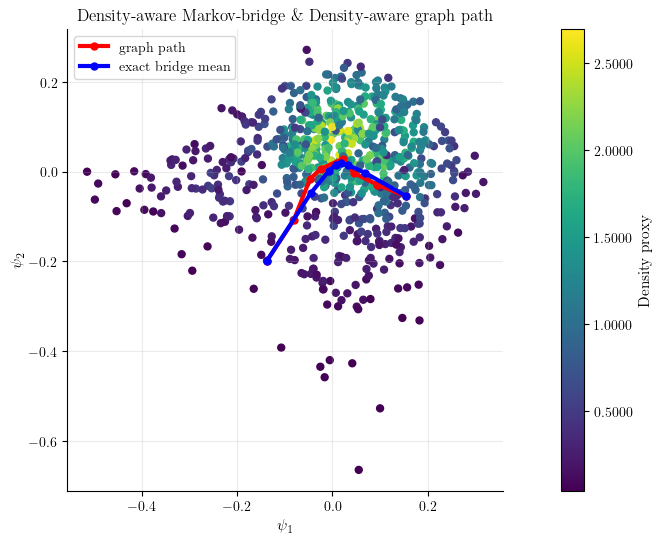

In [ ]:
fig = plt.figure(figsize=(ps.FIG_SINGLE_SQ[0]+1.5, ps.FIG_SINGLE_SQ[1]))
ax = fig.add_subplot()

sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=rho, cmap="viridis")
ax.plot(Psi[density_path, 0], Psi[density_path, 1], c="r", marker="o", linewidth=3, label="graph path")
ax.plot(avg_bridge_exact[:, 0], avg_bridge_exact[:, 1], c="b", marker="o", linewidth=3, label="exact bridge mean")

ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
ax.set_title(f"Density-aware Markov-bridge \& Density-aware graph path")
fig.colorbar(sc, ax=ax, pad=0.1, label="Density proxy", format=ticker.FormatStrFormatter('%.4f'))
plt.legend(loc="upper left")
plt.savefig("./presentation_figures/da_mb_graph_path_82.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
for i in range(T+1):
    plot_bridge_step_2d(Psi, bridge_marginals_da, t=i, save=f"./presentation_figures/density_aware_markov_bridge82_t{i}.png")

#### Plots for all paths

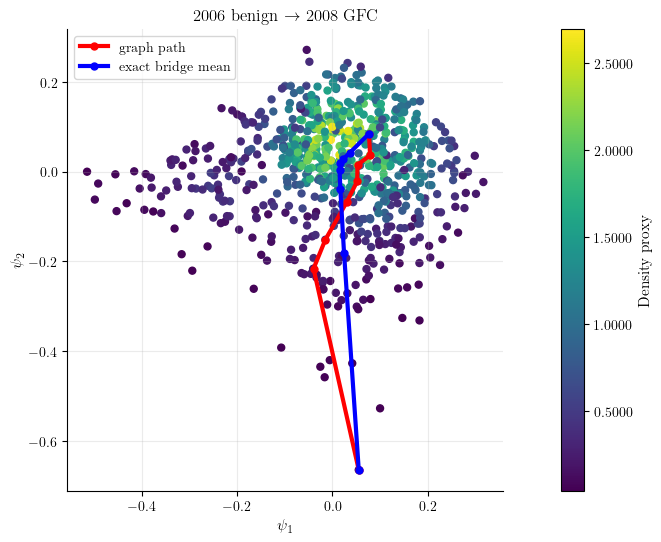

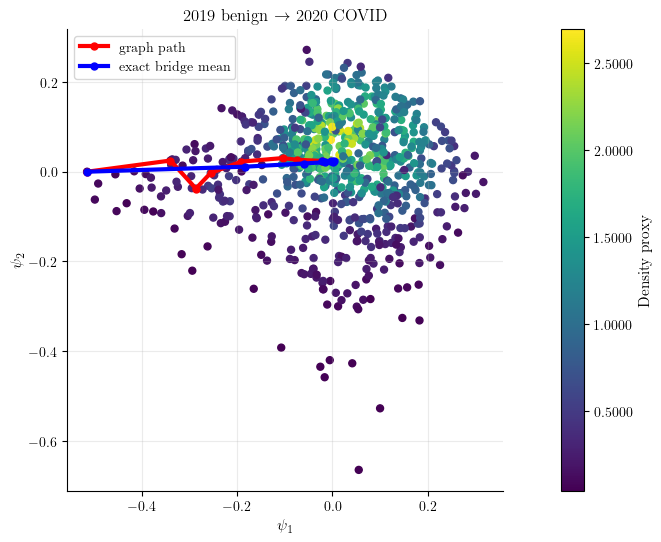

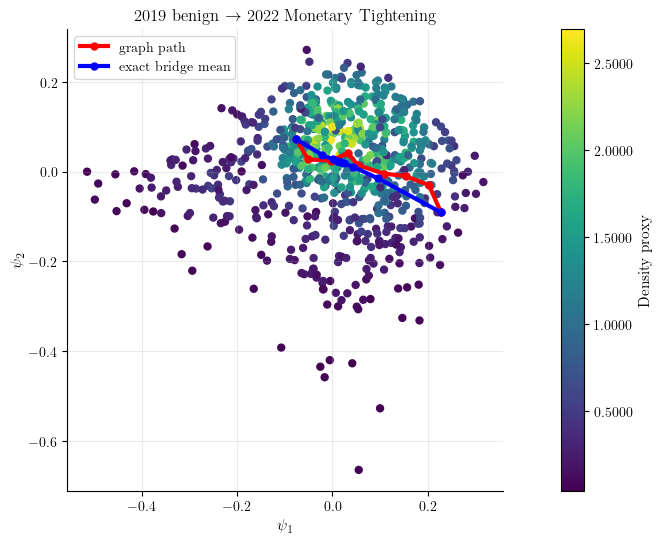

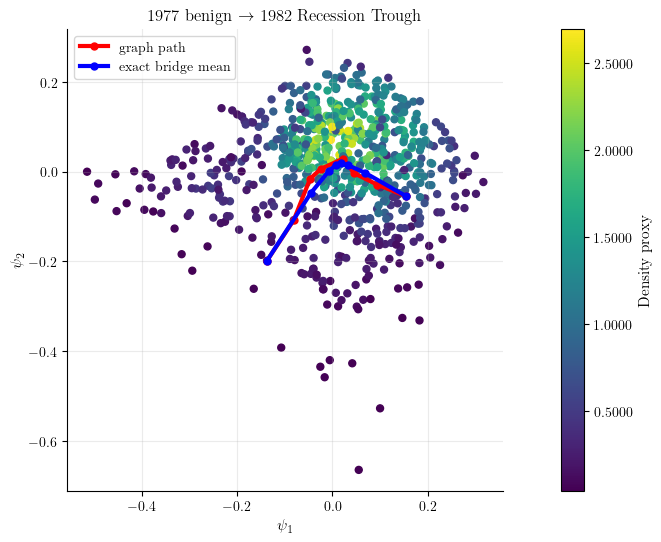

In [107]:
for event, (s, e) in pairs.items():

    density_path = graph_path(A_dist_sym, BETA, V, s, e)
    T = len(density_path) - 1

    beta = 0.25
    density_weight = np.exp(-beta * V)
    P_da = P * density_weight[None, :] 
    q_da = P_da.sum(axis=1)
    P_da = P_da / q_da[:, None]

    bridge_da = compute_markov_bridge(P_da, s, e, T)
    bridge_marginals_da = bridge_da["marginals"]
    bridge_paths_da = sample_markov_bridges(P_da, bridge_da["h"], s, e, n_paths=10_000, seed=42)

    avg_bridge_exact = bridge_marginals_da @ Psi

    fig = plt.figure(figsize=(ps.FIG_SINGLE_SQ[0]+1.5, ps.FIG_SINGLE_SQ[1]))
    ax = fig.add_subplot()

    sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=rho, cmap="viridis")
    ax.plot(Psi[density_path, 0], Psi[density_path, 1], c="r", marker="o", linewidth=3, label="graph path")
    ax.plot(avg_bridge_exact[:, 0], avg_bridge_exact[:, 1], c="b", marker="o", linewidth=3, label="exact bridge mean")

    event_name = event.replace("->", r"$\rightarrow$")

    ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    ax.set_title(event_name)
    fig.colorbar(sc, ax=ax, pad=0.1, label="Density proxy", format=ticker.FormatStrFormatter('%.4f'))
    plt.legend(loc="upper left")
    plt.savefig(f"./presentation_figures/da_mb_graph_path_{event.split(' ')[-1]}.png", dpi=300, bbox_inches="tight")
    plt.show()


# OTHER METRICS TO EXPLORE LATER ---------------------------------------

In [ ]:
def plot_bridge_step(Psi, bridge_marginals, density_path, t, dims=(0, 1, 2)):
    """
    Plot the exact Markov-bridge distribution at one step.

    Calculations can use all diffusion dimensions.
    dims controls only the 3D visualisation.
    """

    Psi = np.asarray(Psi)
    density_path = np.asarray(density_path)

    if not 0 <= t < len(density_path):
        raise ValueError("t is outside the path.")

    p = bridge_marginals[t]

    x, y, z = dims

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Background manifold
    ax.scatter(Psi[:, x], Psi[:, y], Psi[:, z], s=8, alpha=0.12)

    # Relative marker sizes make low probabilities visible
    relative_prob = np.sqrt(p / (p.max() + 1e-300))

    sc = ax.scatter(Psi[:, x], Psi[:, y], Psi[:, z], c=p, s=8 + 80 * relative_prob, cmap="viridis", alpha=0.85)

    # Deterministic density-aware path
    G = Psi[density_path]
    ax.plot(G[:, x], G[:, y], G[:, z], linewidth=2.5, label="Density-aware path")

    # Point on deterministic path corresponding to this t
    ax.scatter(G[t, x], G[t, y], G[t, z], s=130, marker="X", label=f"Density path, step {t}")
    ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$"); ax.set_zlabel(r"$\psi_3$")
    ax.set_title(f"Markov-bridge distribution at step {t}")
    fig.colorbar(sc, ax=ax, pad=0.1, label="Bridge probability")
    ax.legend(); plt.show()


In [ ]:
def path_bridge_support(Psi, bridge_marginals, density_path, k=15):
    """
    Compare each deterministic path point with the bridge
    distribution at the corresponding step.
    """

    Psi = np.asarray(Psi, dtype=float)
    density_path = np.asarray(density_path, dtype=int)

    T = bridge_marginals.shape[0] - 1

    if len(density_path) != T + 1:
        raise ValueError("density_path and bridge must have the same number of points.")

    k = min(k, len(Psi))

    nn = NearestNeighbors(n_neighbors=k).fit(Psi)

    neighbourhoods = nn.kneighbors(Psi[density_path], return_distance=False)

    rows = []

    for t, node in enumerate(density_path):

        p = bridge_marginals[t]

        # Probability of exact deterministic path node
        exact_probability = p[node]

        # Probability in its k-nearest-node neighbourhood
        neighbourhood_mass = p[neighbourhoods[t]].sum()

        # Another useful measure:
        # expected diffusion distance between the bridge
        # and the deterministic path point
        distances = np.linalg.norm(Psi - Psi[node], axis=1)

        expected_distance = np.sum(p * distances)

        rows.append({"step": t, "path_node": node, 
                     "exact_node_probability": exact_probability, 
                     f"knn_{k}_probability": neighbourhood_mass, 
                     "expected_diffusion_distance": expected_distance})

    return pd.DataFrame(rows)


support = path_bridge_support(Psi, bridge_marginals, density_path, k=15)
display(support)

,step,path_node,exact_node_probability,knn_15_probability,expected_diffusion_distance
0,0,151,1.000000,1.000000,0.000000
1,1,230,0.007288,0.056457,0.148328
2,2,638,0.002370,0.033445,0.152019
3,3,636,0.002919,0.039006,0.142835
4,4,262,0.002879,0.041522,0.152301
5,5,624,0.002795,0.043395,0.160302
6,6,679,0.001194,0.035760,0.202518
7,7,217,1.000000,1.000000,0.000000


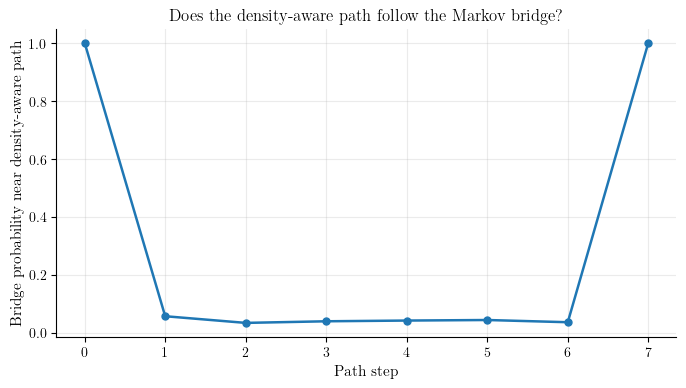

In [ ]:
k_column = "knn_15_probability"

plt.figure(figsize=(8, 4))

plt.plot(support["step"],support[k_column], marker="o")

plt.xlabel("Path step")
plt.ylabel("Bridge probability near density-aware path")
plt.title("Does the density-aware path follow the Markov bridge?")

plt.grid(alpha=0.25)
plt.show()

In [ ]:
def calculate_path_metrics(paths, Psi, rho, V, beta):
    paths = np.asarray(paths, dtype=int)
    single_path = paths.ndim == 1
    if single_path: paths = paths[None, :]
    coords = Psi[paths]
    step_lengths = np.linalg.norm(np.diff(coords, axis=1), axis=2)
    path_density = rho[paths]; path_V = V[paths]
    weighted_edges = (step_lengths * np.exp(beta * (path_V[:, :-1] + path_V[:, 1:]) / 2))
    results = pd.DataFrame({"min_density": path_density.min(axis=1), "mean_density": path_density.mean(axis=1),
                            "path_length": step_lengths.sum(axis=1), "density_aware_cost": weighted_edges.sum(axis=1)})

    if single_path: return results.iloc[0]
    return results


bridge_metrics = calculate_path_metrics(bridge_paths, Psi, rho, V, BETA)
density_path_metrics = calculate_path_metrics(density_path, Psi, rho, V, BETA)
display(bridge_metrics.describe())
print("\nDensity-aware path:")
display(density_path_metrics)

,min_density,mean_density,path_length,density_aware_cost
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.162237,1.190307,1.296536,2.474121
std,0.014269,0.193139,0.219169,2.223486
min,0.040794,0.419129,0.747976,0.771498
25%,0.165108,1.062136,1.146036,1.430621
50%,0.165108,1.193189,1.276652,1.888724
75%,0.165108,1.323953,1.425025,2.741203
max,0.165108,1.828582,2.822583,65.322601



Density-aware path:


min_density           0.165108
mean_density          1.371533
path_length           0.502642
density_aware_cost    1.274489
Name: 0, dtype: float64

In [ ]:
def plot_bridge_metric(bridge_metrics, density_path_metrics, metric="min_density", bins=50):
    """
    Histogram of a bridge path statistic with the
    deterministic density-aware path marked.
    """

    values = bridge_metrics[metric]
    deterministic_value = float(density_path_metrics[metric])
    percentile = (100 * np.mean(values <= deterministic_value))

    plt.figure(figsize=(8, 4.5))
    plt.hist(values,bins=bins,alpha=0.75)
    plt.axvline(deterministic_value,linestyle="--",linewidth=2,label=(f"Density-aware path = {deterministic_value:.4g}"))
    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel("Number of bridge paths")
    plt.title(f"Markov bridge distribution: {metric.replace('_', ' ')}")
    plt.legend(title=f"Percentile: {percentile:.1f}%")
    plt.show()

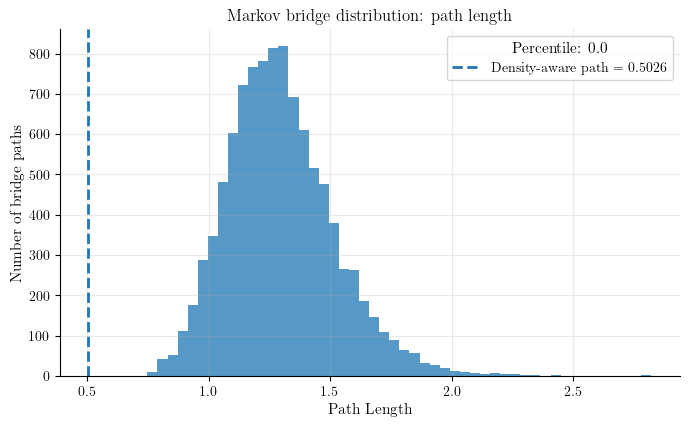

In [ ]:
plot_bridge_metric(bridge_metrics, density_path_metrics, metric="path_length")